In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
table {margin-left:0 !important; margin-right: auto;}
</style>
"""))

<font size="5" color="black">ch3. 분류 분석</font>

# 1. 분류 분석(Classification Analysis)

* **분류 분석의 정의**
    * 데이터의 독립변수(속성)를 활용한 분류 기준 수립 과정
    * 타겟변수(종속변수)가 범주형(Categorical)인 지도학습 분석 기법


* **주요 활용 사례**
    * 고객 등급 예측, 휴면 고객 전환 예측, 상품 구매 여부 예측, 보험 사기자 탐지 등


* **주요 라이브러리 및 설치**
    * Python 대표 머신러닝 패키지 : `scikit-learn`
    * 설치 명령어: `pip install scikit-learn`


## Scikit-learn 제공 데이터셋 접근 방식

### Load 계열 (패키지 내장 데이터셋)
* 패키지 설치 시 함께 제공되는 소규모 실습용 데이터셋
* 별도 네트워크 연결 없이 즉시 로드 가능
    * `load_iris()` (붓꽃 데이터), `load_boston()` (보스턴 주택 가격 데이터, *현재는 사용 권장되지 않음*)

In [2]:
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

In [3]:
# MNIST 데이터 셋 로드
(X_train, y_train), (X_test, y_test) = mnist.load_data()

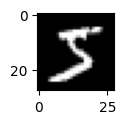

In [4]:
# 첫번째 숫자이미지 출력
plt.figure(figsize=(1,1))
plt.imshow(X_train[0], cmap='gray')
plt.show()

### Fetch 계열 (외부 다운로드 데이터셋)
* 데이터의 크기가 크거나 지속 업데이트가 필요한 대규모 데이터셋
* 최초 실행 시 인터넷 연결을 통한 자동 다운로드 및 캐싱
    * `fetch_covtype()` (토지 피복 유형 데이터), `fetch_20newsgroups()` (20가지 주제의 뉴스그룹 텍스트 말뭉치)

In [5]:
from sklearn.datasets import fetch_openml
import numpy as np

In [6]:
# MNIST 데이터 셋 다운로드
mnist = fetch_openml(
    name='mnist_784',
    version=1,
    as_frame=False, # 데이터 프레임 변환 여부 (기본값 : auto, False 시 넘파이 배열)
    parser='auto' # 파싱 방식 설정
)

In [7]:
X = mnist.data.astype(np.uint8)
y = mnist.target.astype(np.uint8)

In [8]:
X = X.reshape(70000, 28, 28)
X.shape, y.shape

((70000, 28, 28), (70000,))

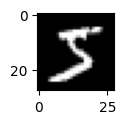

In [9]:
# 첫번째 숫자이미지 출력
plt.figure(figsize=(1,1))
plt.imshow(X[0], cmap='gray')
plt.show()

### Make 계열 (가상 데이터 생성)
* 알고리즘의 동작 원리 이해 및 성능 테스트 목적으로 생성하는 가상 데이터셋
* 데이터의 노이즈, 특성 수, 클래스 분리도 등을 사용자가 지정 가능
    *  `make_classification()` (분류 모델 실험용 가상 데이터 생성), `make_regression()` (회귀 모델 실험용 가상 데이터 생성)

In [10]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

# 가상 분류 데이터 셋 생성
X_cls, y_cls = make_classification(
    n_samples=500,  # 샘플 개수
    n_features=2,  # 전체 특성 수 (2D 시각화를 위해 2개로 설정)
    n_informative=2,  # 예측에 유용한 특성 수
    n_redundant=0,  # 다른 특성의 선형 결합으로 만들어진 불필요한 특성 수
    n_classes=2,  # 클래스 개수 (이진 분류)
    class_sep=1.2,  # 클래스 간 분리도 (값이 클수록 구분이 쉬움)
    random_state=42,
    n_clusters_per_class=1 # 클래스 당 군집 수
)

In [11]:
# 데이터 구조 확인
print(X_cls.shape, y_cls.shape)

(500, 2) (500,)


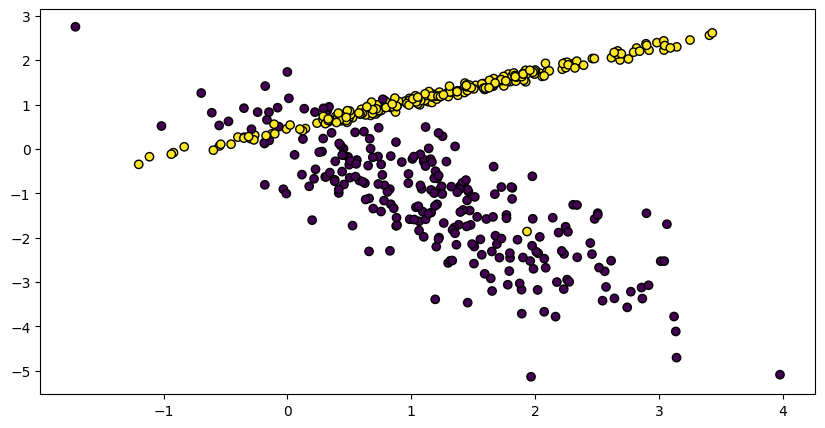

In [12]:
plt.figure(figsize=(10, 5))
plt.scatter(
    X_cls[:, 0],
    X_cls[:, 1],
    c=y_cls,
    edgecolors="k",
)
plt.show()

# 2. 분류 분석의 종류


## 2.1 확률적 모델

* **확률적 모델의 정의**
    * 입력 데이터에 대해 각 범주(Class)가 정답일 조건부 확률을 산출하는 분류 모델
    * 예측의 불확실성/확신도 측정 가능

* **`predict_proba()`**
    * 각 입력 샘플이 각 클래스에 속할 확률값(0.0 ~ 1.0)을 반환 (모든 클래스 확률의 합은 1)
    * 임계값(Threshold) 조정 및 이진/다중 분류의 정밀한 예측 판단에 활용


* **`predict_log_proba()`**
    * `predict_proba()` 결과에 자연로그(ln)를 적용한 값 반환
    * 언더플로우(Underflow, 매우 작은 확률 곱셈 시 발생하는 연산 오류) 방지 및 계산 안정성 확보 목적

## 2.1.1 확률적 생성 모델

```
QDA : sklearn.discriminant_analysis.QuadraticDiscriminantAnalysis`
NB : sklearn.naive_bayes.MultinomialNB
```

* **베이즈 정리 기반 확률 계산 :** 데이터의 각 클래스별 특징 확률 분포를 추정한 후, 베이즈 정리를 적용하여 사후 확률 산출
    - 베이즈 정리(Bayes' theorem) : 새로운 정보나 데이터가 주어졌을 때 기존의 확률(사전 확률)을 업데이트하여 사후 확률 계산
* **데이터 효율성 :** 사전 확률 및 우도(Likelihood) 분포를 활용하여 소량의 데이터셋 환경에서도 안정적인 학습 및 예측 수행
    - 우도(Likelihood) 분포 : 특정 파라미터가 주어졌을 때 관측된 데이터가 나타날 확률 density/mass를 파라미터에 대한 함수로 표현한 분포

### QDA (Quadratic Discriminant Analysis)
* 변수 간 비선형 관계 포착에 유용하며, 데이터 수가 충분하고 클래스 간 변동성이 다를 때 효과적
* 각 클래스별 독립변수 X의 분포가 정규분포를 따른다고 가정
* 클래스마다 서로 다른 공분산 행렬(Covariance Matrix)을 허용하여 곡선 형태의 이차(Quadratic) 경계면 형성

In [13]:
# 데이터
from sklearn.datasets import make_classification
X, y = make_classification(
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    n_clusters_per_class=1,
    random_state=9
)

X.shape, y.shape

((100, 2), (100,))

In [14]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (8,4)

In [15]:
# 난수 재배열 : 대칭 구조 생성
X[y==1] = -X[y==0]

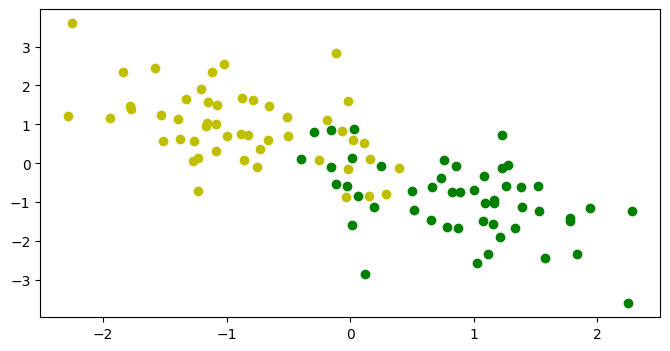

In [16]:
plt.scatter(X[y==0,0],X[y==0,1],c='y')
plt.scatter(X[y==1,0],X[y==1,1],c='g')
plt.show()

In [17]:
# QDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
model=QuadraticDiscriminantAnalysis()
model.fit(X, y)

x = [[0, -1]] # 입력 데이터 : 2차원
p = model.predict_proba(x)

model.predict(x)

array([1])

In [18]:
# 모델의 클래스들
model.classes_

array([0, 1])

In [19]:
# 교차표
import pandas as pd
y_hat = model.predict(X)
pd.crosstab(y, y_hat, colnames=['예측'], rownames=['실제'])

예측,0,1
실제,,
0,44,6
1,6,44


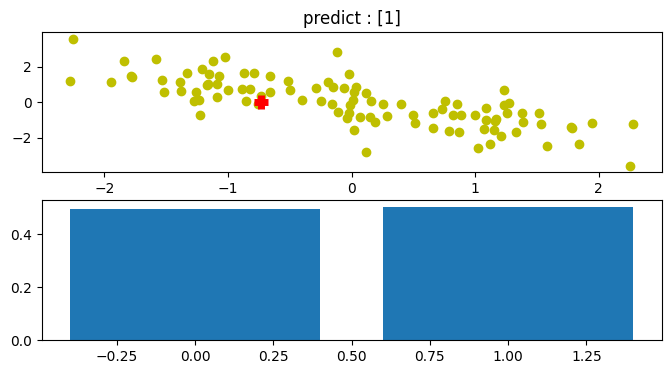

In [20]:
x = [[0.01, 0.02]]
p = model.predict_proba(x)[0]
plt.subplot(211)
plt.scatter(x=X[:,0], y=X[:,1], c='y')
plt.scatter(x=X[0][0], y=x[0][1], c='r', s=100, marker='+', lw=5)
h = model.predict(x)
plt.title(f'predict : {h}')

plt.subplot(212)
plt.bar(model.classes_, p)
plt.show()

### NB (Naive Bayesian)
- 클래스가 주어졌을 때 모든 독립변수들은 서로 통계적으로 완전 독립이라는 가정
- 강력한 독립성 가정을 통해 파라미터 수를 줄여 계산 복잡도를 크게 낮추며, 대용량 텍스트 분류(스팸 필터링, 감성 분석 등) 및 소규모 데이터셋에서 높은 성능 발휘

In [21]:
import warnings

warnings.filterwarnings("ignore", message="X does not have valid feature names")

predictions = model.predict(X)

In [22]:
import seaborn as sns
iris = sns.load_dataset('iris')

X = iris.iloc[:,:-1]
y = iris.iloc[:,-1]

In [23]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X, y)

x = [[5.1, 3.5, 1.4, 0.2]]
h = model.predict(x)
p = model.predict_log_proba(x)

print('예측 :', h[0])
print(model.classes_)
print(p[0])

예측 : setosa
['setosa' 'versicolor' 'virginica']
[-0.28502512 -1.82678902 -2.44098368]


<BarContainer object of 3 artists>

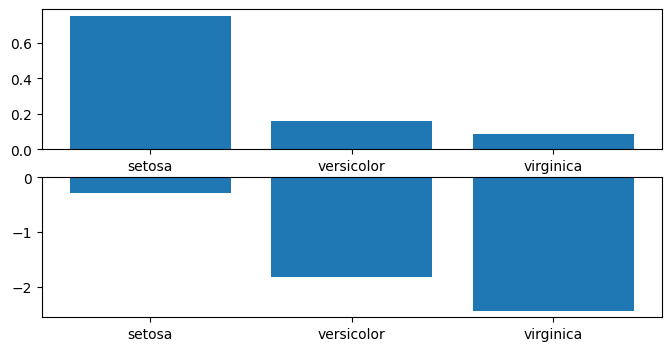

In [24]:
plt.subplot(211)
plt.bar(model.classes_, model.predict_proba(x)[0])

plt.subplot(212)
plt.bar(model.classes_, model.predict_log_proba(x)[0])

In [25]:
model.score(X, y)

0.9533333333333334

## 2.1.2 확률적 판별 모델

```
LR : sklearn.linear_model.LogisticRegression
DT : sklearn.tree.DecisionTreeClassifier
```

* **조건부 확률 분포 직접 추정 :** 데이터의 분포를 별도로 모델링하지 않고, 입력 특징에 대한 클래스 확률을 직접 추정
* **우수한 예측 성능 및 높은 해석 가능성 :** 결합 분포 추정에 따른 계산 복잡도를 줄여 실전 예측 성능이 뛰어나며, 계수(Weight) 분석을 통한 직관적 해석 용이

### 로지스틱 회귀 (Logistic Regression)
-  종속변수가 범주형/이진(0 또는 1, Success/Failure)일 경우

In [26]:
# 가상 데이터 셋 생성
X, y = make_classification(
    n_samples=100,
    n_features=1,
    n_redundant=0,
    n_informative=1,
    n_clusters_per_class=1,
    random_state=1
)

In [27]:
np.c_[X,y][:3]

array([[-1.65902848,  0.        ],
       [-0.64202884,  0.        ],
       [-1.53918976,  0.        ]])

In [28]:
# 모델 생성
from sklearn.linear_model import LogisticRegression
model = LogisticRegression().fit(X, y)

In [29]:
# 모델 예측용 데이터
x_data = np.linspace(-3, 3, 100) # 1차원 데이터
x_data = np.expand_dims(x_data, axis=1) # 축 확장 (1차원 → 2차원)

In [30]:
prob = model.predict_proba(x_data)
prob[:3]

array([[9.99986168e-01, 1.38320570e-05],
       [9.99982885e-01, 1.71146738e-05],
       [9.99978824e-01, 2.11763030e-05]])

In [31]:
prob0 = prob[:, 0] # 0일 확률
prob1 = prob[:, 1] # 1일 확률

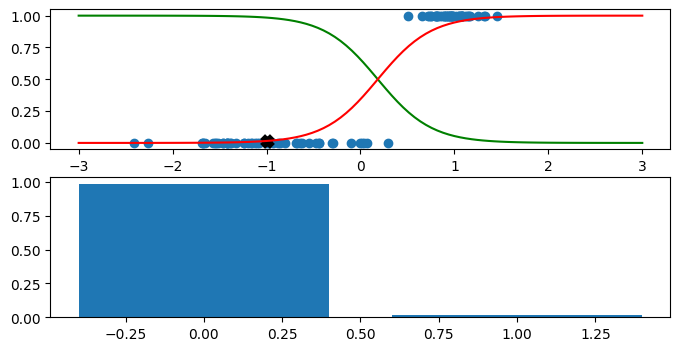

In [32]:
plt.subplot(211)
plt.scatter(X, y)
plt.plot(x_data, prob0, c='g')
plt.plot(x_data, prob1, c='r')
x = [[-1]]
prob_x = model.predict_proba(x)[0]
plt.scatter(x[0], prob_x[1], marker='x', c='k', lw=5, s=50)

plt.subplot(212)
plt.bar(model.classes_, prob_x)
plt.show()

### 의사 결정 나무 (Decision Tree)
- 여러 개의 독립변수 조건을 순차적으로 적용하여 독립변수 전체 공간을 상호 배타적인 영역으로 분할하는 분류 모형
- 트리 구조 형태 : Root Node(뿌리 노드)에서 시작하여 Decision Node(중간 노드)의 조건 판단을 거쳐 Leaf Node(최종 끝 노드)에서 예측 클래스를 결정
    * 우수한 직관성 및 해석력 : 시각화가 쉬우며, 데이터 스케일링(정규화/표준화) 등의 전처리 영향이 적음
    * 과적합(Overfitting) 위험 : 트리가 깊어질수록 과적합 가능성이 높아져 가지치기(Pruning) 및 하이퍼파라미터(`max_depth` 등) 조절 필수

In [33]:
from sklearn.datasets import load_iris
data = load_iris()
X = data.data[:, 2:]
y = data.target
feature_names = [name[:5] for name in data.feature_names[2:]]

In [34]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(
criterion='entropy',  # 분할 기준 : 정보 이득이 높은 방향으로 가지를 치도록 '엔트로피' 지표 사용
    max_depth=1, # 나무의 최대 깊이 : 1단계만 가지치기 진행
    random_state=0
)

dt_model.fit(X, y)

DecisionTreeClassifier(criterion='entropy', max_depth=1, random_state=0)

In [35]:
import io
from sklearn.tree import export_graphviz
import pydot
from IPython.core.display import Image

In [36]:
def draw_decision_tree(model, feature_names):
    dot_buf = io.StringIO()
    export_graphviz(model, out_file=dot_buf, feature_names=feature_names)
    graph = pydot.graph_from_dot_data(dot_buf.getvalue())[0]
    image = graph.create_png()
    return Image(image)

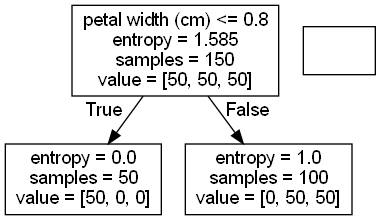

In [37]:
draw_decision_tree(dt_model, feature_names=data.feature_names[2:])

In [38]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

def plot_decision_regions(X, y, model, title):
    species = ['setosa', 'versicolor', 'virginica']
    resolution = 0.01
    markers = ('s', '^', 'o')
    colors = ('red', 'blue', 'lightgreen')
    cmap = mpl.colors.ListedColormap(colors)
    
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution), np.arange(x2_min, x2_max, resolution))
    
    Z = model.predict(np.array([xx1.ravel(), xx2.ravel()]).T).reshape(xx1.shape)
    
    plt.contour(xx1, xx2, Z, cmap=mpl.colors.ListedColormap(['k']))
    plt.contourf(xx1, xx2, Z, alpha=0.4, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(
            x=X[y == cl, 0], 
            y=X[y == cl, 1], 
            alpha=0.8,
            c=[cmap(idx)], 
            marker=markers[idx], 
            s=80, 
            label=species[cl])
        
    plt.xlabel(data.feature_names[2])
    plt.ylabel(data.feature_names[3])
    plt.legend(loc='upper left')
    plt.title(title)
    
    return Z

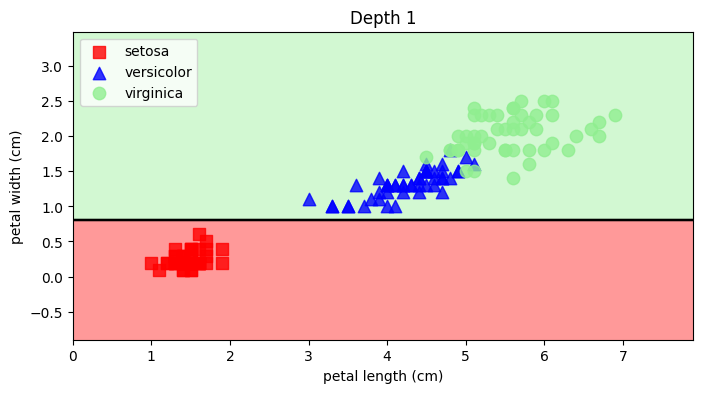

In [39]:
plot_decision_regions(X, y, dt_model, "Depth 1")
plt.show()

In [40]:
x_data = [[1.5, 0.2]]
dt_model.predict(x_data)

array([0])

In [41]:
dt_model.predict_proba(x_data)[0]

array([1., 0., 0.])

In [42]:
dt_model.score(X, y)

0.6666666666666666

In [43]:
dt_model5 = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=0
)
dt_model5.fit(X, y)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=0)

In [44]:
dt_model5.score(X, y)

0.9933333333333333

In [45]:
dt_model5.predict(x_data)

array([0])

In [46]:
dt_model5.predict_proba(x_data)[0]

array([1., 0., 0.])

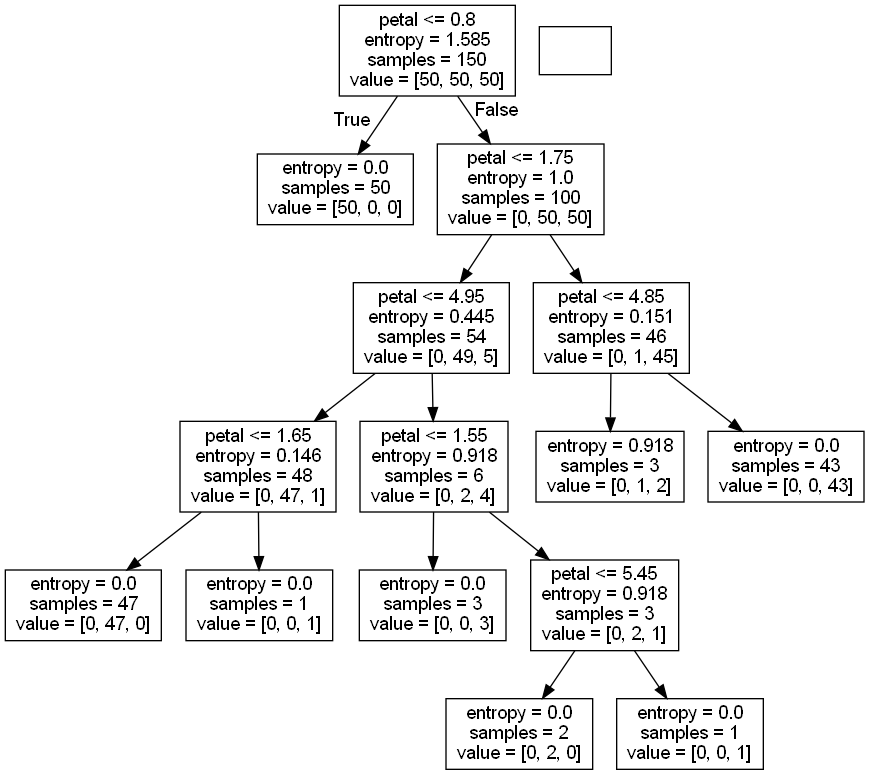

In [47]:
draw_decision_tree(dt_model5, feature_names)

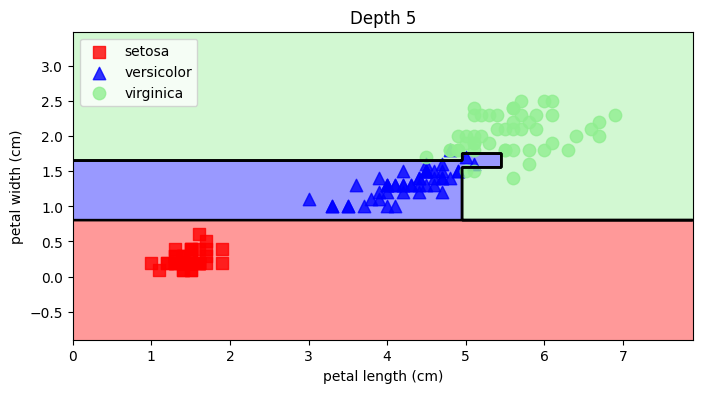

In [48]:
plot_decision_regions(X, y, dt_model5, "Depth 5")
plt.show()

## 2.2 판별 함수 모델 (Discriminative Function Models)
```
Perceptron : sklearn.linear_model.Perceptron
SVM : sklearn.svm.SVC
NN : sklearn.neural_network.MLPClassifier (predict_proba())
```

* 데이터를 클래스별 영역으로 분할하는 **결정 경계(Decision Boundary)** 탐색 모델
* 경계면으로부터 대상 데이터까지의 위치/거리를 계산하는 판별 함수 활용
* 확률 산출 절차 없이 데이터의 속성을 경계면에 직접 Mapping하여 속한 클래스를 판단

* `decision_function()`
    * 입력 샘플과 결정 경계면 사이의 **signed distance(부호가 있는 거리)** 또는 판별 점수 반환
    * 서포트 벡터 머신(SVM), 선형 판별 분석(LDA) 등 대표적 판별 모델에서 활용

### Perceptron

In [49]:
from sklearn.datasets import load_iris
import numpy as np
iris = load_iris()
iris.data [:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [50]:
# 행 0 ~ 49 + 100 ~ 149, 열 0, 1
X = np.r_[iris.data[:50,:2], iris.data[100:,:2]]
y = np.r_[iris.target[:50], iris.target[100:]]
X.shape, y.shape

((100, 2), (100,))

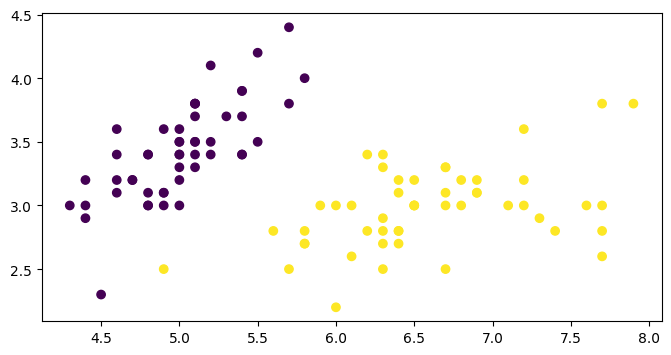

In [51]:
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:,1], c=y)

In [52]:
from sklearn.linear_model import Perceptron

model = Perceptron(
    max_iter=100, # 최대 학습 에포크(Epoch) 수
    eta0=0.1, # 학습률(Learning Rate, η)
    random_state=1
).fit(X, y)

In [53]:
import pandas as pd
y_pred = model.predict(X)
pd.crosstab(y, y_pred, rownames=['true'], colnames=['pred'])

pred,0,2
true,,
0,49,1
2,0,50


In [54]:
# 잘못 예측한 값 찾아보기
for idx, (real, pred) in enumerate(zip(y, y_pred)):
    if real != pred:
        print(f'{idx} 번째 - 실제값 : {real}, 예측값 : {pred}')

41 번째 - 실제값 : 0, 예측값 : 2


In [55]:
x_data = [[4.5, 2.3]]
print('예측 : ', model.predict(x_data))
print(model.decision_function(x_data))

예측 :  [2]
[1.24]


In [56]:
x_data = X[0][np.newaxis, :]
print('예측 : ', model.predict(x_data))
print(model.decision_function(x_data))

예측 :  [0]
[-3.134]


### SVC

In [57]:
from sklearn.svm import SVC

In [58]:
model = SVC(
    C=0.01, # 규제 매개변수 : 값이 클수록 오차를 적게 허용(오버피팅 위험), 작을수록 규제 강해짐(언더피팅 위험)
    kernel='rbf', # 커널 함수 종류 : 'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'
    gamma='scale', # RBF, Poly, Sigmoid 커널의 영향력 범위 : 'scale', 'auto', 또는 실수
    coef0=0.0, # Poly 및 Sigmoid 커널에서 사용되는 독립항(상수항) 값
    shrinking=True, # 축소(Shrinking) 기법 사용 여부
    probability=False, # 확률 추정(predict_proba) 활성화 여부
    tol=0.001, # 학습 중단 결정에 사용할 정지 기준 오차 공차
    class_weight=None, # 클래스 불균형 처리 : 'balanced' 지정 시 클래스 빈도에 역비례하는 가중치 자동 부여
    max_iter=-1 # 최대 반복 횟수 제한
)

model.fit(X, y)

SVC(C=0.01)

In [59]:
x_data = [[4.5, 2.3]]
print(model.predict(x_data))
print(model.decision_function(x_data))

[0]
[-0.16699339]


### NN (MLP)

In [60]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(
    hidden_layer_sizes=(50, 50, 30),
    max_iter=500
)
mlp.fit(X, y)

MLPClassifier(hidden_layer_sizes=(50, 50, 30), max_iter=500)

In [61]:
pred = mlp.predict(X)
pd.crosstab(y, pred)

col_0,0,2
row_0,,
0,50,0
2,0,50


# 3. 분류모델 성능평가

## 3.1 sklearn

* 예측 모델의 score 메서드
    * 예측 모델의 score(test_x, test_y) 함수 기본 제공 (분류모델: 정확도 반환, 회귀모델: 결정계수 반환)

* metrics 패키지 함수
    * 분류 모델 성능 검증을 위한 `sklearn.metrics` 모듈 (혼돈행렬, 정밀도, 재현율, ROC-AUC 등 평가 지표 함수)

* scoring 매개 변수
    * GridSearchCV 및 cross_val_score 등 교차검증 수행 시 성능 평가 기준을 설정하는 매개변수 (`scoring='accuracy'`, `'f1'`, `'roc_auc'` 등)


## 3.2 혼돈행렬

* accuracy (정확도) : 전체 예측 대상 중 올바르게 분류한 비율
* recall (재현율, 민감도) : 실제 양성 데이터 중 양성으로 올바르게 감지한 비율
* precision (정밀도) : 양성으로 예측한 결과 중 실제 양성인 비율
* Specificity (특이도) : 실제 음성 데이터 중 음성으로 올바르게 감지한 비율
* FP Rate (위양성율, False Positive Rate) : 실제 음성 데이터 중 양성으로 잘못 분류한 비율
* f1-score : 정밀도와 재현율의 균형을 평가하는 조화평균 지표
* f-beta score : 가중치 매개변수를 통해 정밀도와 재현율의 중요도를 조절한 종합 지표

In [62]:
# 보험 사기 예측의 실제값과 예측값
import pandas as pd
result = pd.read_csv('data/model_result.csv')
result.head()

,CUST_ID,y_true,y_pred
0,37,0,0
1,51,0,0
2,60,0,0
3,65,0,0
4,73,0,0


In [63]:
# 결측치 여부
result.isna().sum()

CUST_ID    0
y_true     0
y_pred     0
dtype: int64

In [64]:
# 비율
print('전체 데이터 수 :', result.shape[0])
print('F:T 비율 : \n', result.y_true.value_counts(normalize=True))

전체 데이터 수 : 1793
F:T 비율 : 
 0    0.91188
1    0.08812
Name: y_true, dtype: float64


In [65]:
# 혼돈행렬 - pandas
pd.crosstab(result.y_true, result.y_pred, margins=True)

y_pred,0,1,All
y_true,,,
0,1613,22,1635
1,81,77,158
All,1694,99,1793


In [66]:
# 혼돈행렬 - sklearn
from sklearn.metrics import confusion_matrix
confusion_matrix(result.y_true, result.y_pred)

array([[1613,   22],
       [  81,   77]], dtype=int64)

In [67]:
# 이진 분류에서의 성능 평가 지표
from sklearn.metrics import accuracy_score, recall_score, precision_score
print('Accuracy :', accuracy_score(result.y_true, result.y_pred))
print('Precision :', precision_score(result.y_true, result.y_pred))
print('Recall :', recall_score(result.y_true, result.y_pred))

Accuracy : 0.9425543781372002
Precision : 0.7777777777777778
Recall : 0.4873417721518987


In [68]:
# 다중 분류에서의 Precision, Recall

print('Precision :', precision_score(result.y_true, result.y_pred, average='macro'))
print('Recall :', recall_score(result.y_true, result.y_pred, average='macro'))

# average : 다중 클래스 분류 문제에서 각 클래스별로 산출된 정밀도와 재현율을 하나로 종합하는 방식
# - binary (기본값) : 이진 분류, 1(양성) 클래스에 대한 정밀도 및 재현율만 단일값으로 계산
# - macro (매크로 평균) : 각 클래스별로 평가 지표를 개별 계산한 후 단순 단순평균을 산출
# - micro (마이크로 평균) : 전체 클래스의 총 TP, FP, FN 수치를 모두 합산하여 단일 지표로 계산
# - weighted (가중 평균) : 각 클래스별 실제 데이터 개수(샘플 수)를 가중치로 사용하여 평균을 산출

Precision : 0.8649809786173422
Recall : 0.7369430573297719


In [70]:
# f1-score
from sklearn.metrics import f1_score
print('f1-score :', f1_score(result.y_true, result.y_pred))

f1-score : 0.5992217898832685


In [71]:
# fbeta score
from sklearn.metrics import fbeta_score

# precision의 가중치가 높을 때 (고객의 만족도 우선) ; beta < 1 미만
print('fbeta_score :', fbeta_score(result.y_true, result.y_pred, beta=0.5))

# recall의 가중치가 높을 때 (회사의 비용 감축 우선) ; beta > 1 초과
print('fbeta_score :', fbeta_score(result.y_true, result.y_pred, beta=1.5))

# 각각의 가중치가 같을 때 ; beta = 1 : f1-score
print('fbeta_score :', fbeta_score(result.y_true, result.y_pred, beta=1))
print('   f1-score :', f1_score(result.y_true, result.y_pred))

fbeta_score : 0.6949458483754513
fbeta_score : 0.5506050605060505
fbeta_score : 0.5992217898832685
   f1-score : 0.5992217898832685


In [72]:
# 특이도 (pos_label=0 설정 시 0을 양성 클래스로 간주하여 0 기준의 재현율(즉, 특이도)을 계산함)
spec = recall_score(result.y_true, result.y_pred, pos_label=0)
spec

0.9865443425076452

In [73]:
# 위양성율 (fp rate, 1종 오류(오탐) 비율)
1 - spec

0.013455657492354778

## 3.3 ROC Curve
    - Receiver Operating Characteristic Curve
- ROC Curve : 분류 모델의 임계값(Threshold, 클래스 판별 기준값)을 0에서 1까지 변화시킬 때, 위양성률(Fall-out, FP Rate)의 변화에 따른 재현율(Recall, TP Rate)의 변화 추이를 시각화한 곡선
    - 세로축 : TP rate (재현율)
    - 가로축 : FP rate (위양성율)

In [74]:
from sklearn.datasets import make_classification
X, y = make_classification(
    n_samples=100,
    n_classes=2,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    random_state=0
)

X.shape, y.shape

((100, 2), (100,))

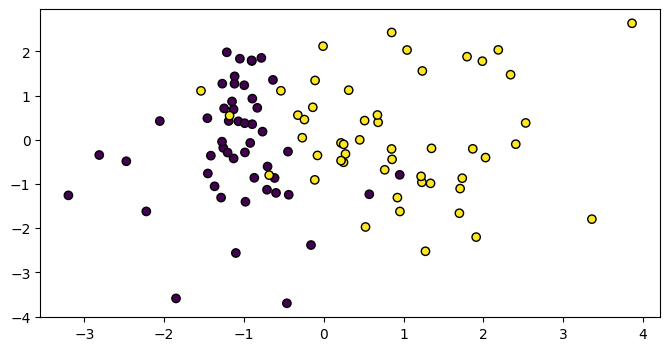

In [75]:
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
plt.show()

In [76]:
from sklearn.svm import SVC
model = SVC(probability=True)
model.fit(X, y)

SVC(probability=True)

In [77]:
y_pred = model.predict(X)

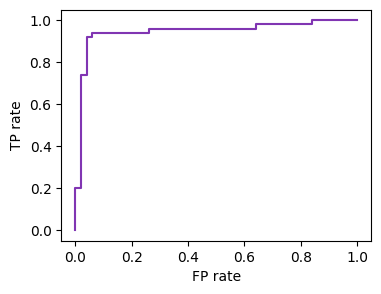

In [78]:
# roc_curve() 함수를 통한 FP Rate 및 TP Rate 산출
    # roc_curve(y, model.decision_function(X))
    # roc_curve(y, model.predict_proba(X)[:,1]) # 1 클래스 확률 선택

from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y, model.decision_function(X))
fpr1, tpr1, thresholds1 = roc_curve(y, model.predict_proba(X)[:,1])
plt.figure(figsize=(4,3))
plt.plot(fpr, tpr, c='b', alpha=0.7)
plt.plot(fpr1, tpr1, c='r', alpha=0.3)
plt.xlabel('FP rate')
plt.ylabel('TP rate')
plt.show()

### 두 모델의 혼돈행렬이 같을 경우

In [79]:
X, y = make_classification(
    n_samples=1000,
    weights=[0.95, 0.05],
    n_classes=2,
    random_state=5
)

X.shape, y.shape

((1000, 20), (1000,))

In [80]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

model1 = LogisticRegression().fit(X, y)
model2 = SVC(gamma=0.0001, C=3000, probability=True).fit(X,y)

pred1 = model1.predict(X)
pred2 = model2.predict(X)

In [88]:
from sklearn.tree import DecisionTreeClassifier
model3 = DecisionTreeClassifier(random_state=42).fit(X, y)
pred3 = model3.predict(X)

In [81]:
# model1의 혼돈행렬
pd.crosstab(y, pred1)

col_0,0,1
row_0,,
0,940,3
1,30,27


In [82]:
# model2의 혼돈행렬
pd.crosstab(y, pred2)

col_0,0,1
row_0,,
0,940,3
1,30,27


In [89]:
# model3의 혼돈행렬
pd.crosstab(y, pred3)

col_0,0,1
row_0,,
0,943,0
1,0,57


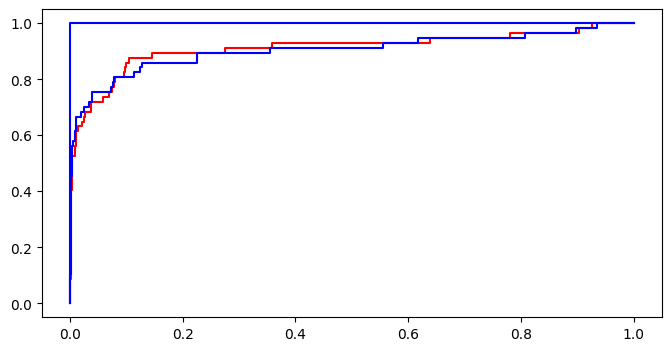

In [91]:
from sklearn.metrics import roc_curve
fpr1, tpr1, thr1 = roc_curve(y, model1.decision_function(X))
fpr2, tpr2, thr2 = roc_curve(y, model2.decision_function(X))
fpr3, tpr3, thr3 = roc_curve(y, model3.predict_proba(X)[:,1])

plt.plot(fpr1, tpr1, c='r')
plt.plot(fpr2, tpr2, c='b')
plt.plot(fpr3, tpr3, c='b')
plt.show()

## 3.4 AUC
    - Area Under the ROC Curve
    
- ROC 커브 아래의 전체 면적을 나타내는 단일 수치 지표 ; 0.5(분류 능력이 없는 모델) ~ 1.0(완벽하게 이상적인 모델)
- 모델이 분류 기준값(임계값)의 변화에 영향을 받지 않고 양성과 음성을 얼마나 명확하게 구분하는지 측정하는 종합 성능 평가 지표

In [92]:
from sklearn.metrics import auc
auc(fpr1, tpr1), auc(fpr2, tpr2), auc(fpr3, tpr3)

(0.9112202563673234, 0.9037227214377407, 1.0)